In [7]:
#import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
!pip install ta # technical indicator's library
import ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=0bcef63dd8f0b9a64abf907c5286e03ac9f9bf6b0c444ce01030c238d6d94ad0
  Stored in directory: /root/.cache/pip/wheels/e3/3a/ee/4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta


**Asset selection :**  \
FMCG is less volatile itcrket and among them itc is choosen because mean, median returns are almost near and it has more number of entries and best volatile, skewness and kurtosis as compare to other FMCG stocks.

In [ ]:
# Read csv file of itc daily ohlcv dataset
df = pd.read_csv("/content/ITC",parse_dates=['date'])
itc = df.set_index(df['date']).drop('date', axis=1).copy()

**Data understanding**

In [ ]:
sorted_data = itc.sort_values(by='date')[['close']]
sorted_data['log_returns'] = np.log(itc['close']/itc['close'].shift(1))

In [ ]:
log_returns = sorted_data.dropna()['log_returns']

In [ ]:
print(f'mean {np.mean(log_returns)*100:.4f}%')
print(f'median {np.median(log_returns)}')
print(f'standard deviation {np.std(log_returns)*100:.4f}%')
print(f'skewness {skew(log_returns):.4f}')
print(f'kurtosis {kurtosis(log_returns,fisher=True):.4f}')
print(f'min {np.min(log_returns)*100:.4f}')
print(f'itcx {np.itcx(log_returns)*100:.4f}')

mean 0.0663%
median 0.00023092021809130258
standard deviation 1.7518%
skewness -0.1415
kurtosis 5.3672
min -13.7157


AttributeError: module 'numpy' has no attribute 'itcx'

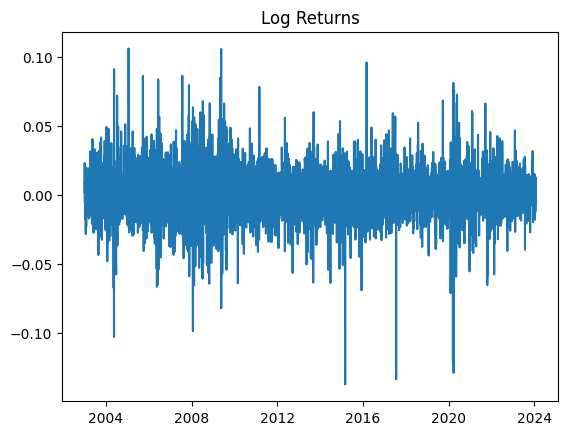

In [ ]:
plt.plot(log_returns)
plt.title('Log Returns')
plt.show()

In [ ]:
# printing basic inforitction
print(itc.shape)
print(itc.info())
print(itc.dtypes)
print(itc.describe())
print(itc.head())

(5236, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5236 entries, 2003-01-01 00:00:00+05:30 to 2024-01-20 00:00:00+05:30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5236 non-null   float64
 1   high    5236 non-null   float64
 2   low     5236 non-null   float64
 3   close   5236 non-null   float64
 4   volume  5236 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 245.4 KB
None
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object
              open         high          low        close        volume
count  5236.000000  5236.000000  5236.000000  5236.000000  5.236000e+03
mean    170.503627   172.311257   168.471484   170.377345  1.495081e+07
std     109.935450   110.769992   108.971169   109.848197  1.138873e+07
min      12.840000    13.610000    12.380000    13.510000  4.570910e+05
25%      62.242500    63.040000    60.990000    62.03500

In [ ]:
print(min(df.date))
print(max(df.date))

2003-01-01 00:00:00+05:30
2024-01-20 00:00:00+05:30


In [ ]:
print("yearly trading days")
df.date.dt.year.value_counts()

yearly trading days


,count
date,
2020,254
2010,254
2003,253
2007,252
2005,251
2021,251
2015,251
2013,250
2006,250


In [ ]:
# Code imported from ChatGPT to print OHLCV data
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3]
)

# OHLC candlestick
fig.add_trace(
    go.Candlestick(
        x=itc.index.values,
        open=itc["open"],
        high=itc["high"],
        low=itc["low"],
        close=itc["close"],
        name="OHLC"
    ),
    row=1,
    col=1
)

# Volume
fig.add_trace(
    go.Bar(
        x=itc.index.values,
        y=itc["volume"],
        name="Volume"
    ),
    row=2,
    col=1
)

fig.update_layout(
    title="ITC OHLCV Data",
    xaxis_rangeslider_visible=False,
    height=700
)

fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="Volume", row=2, col=1)
print("if you observe there is no such suspecious moment")


fig.show()

if you observe there is no such suspecious moment


In [ ]:
itc = itc.sort_values(by='date')

In [ ]:
itc.describe()

,open,high,low,close,volume
count,5236.000000,5236.000000,5236.000000,5236.000000,5.236000e+03
mean,170.503627,172.311257,168.471484,170.377345,1.495081e+07
std,109.935450,110.769992,108.971169,109.848197,1.138873e+07
min,12.840000,13.610000,12.380000,13.510000,4.570910e+05
25%,62.242500,63.040000,60.990000,62.035000,8.276400e+06
50%,193.310000,195.470000,190.600000,193.300000,1.159673e+07
75%,243.962500,246.260000,240.977500,243.675000,1.754120e+07
max,493.450000,499.700000,487.000000,492.150000,1.494797e+08


1) As per abouve output there are no negative prices and volumes
2) No suspecious volume detected
3) Almost all columns are in good range

**Data quality checks**

In [ ]:
print(df.duplicated().sum())

46


In [ ]:
# Analysing duplicates
row_duplicates = df.apply(lambda x: x.duplicated(keep=False).sum(),axis=1)
col_duplicates = df.apply(lambda x: x.duplicated(keep=False).sum(),axis=0)

In [ ]:
col_duplicates

,0
date,92
open,2684
high,2398
low,2407
close,1995
volume,96


**There are lot of duplicates in dataset row wise and column wise exist some outliers**

In [ ]:
# #Checking missing values
#print(df.isna().any())
print(df.isna().sum())
print("There are no null vlues found")

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64
There are no null vlues found


**There are no missing values found**

**candle quality checks**

In [ ]:
invalid_ohlc = itc[
    (itc['high'] < itc['low']) &
    (itc['high'] < itc['open']) &
    (itc['high'] < itc['close']) &
    (itc['open'] > itc['close']) ]

**Code has good quality.means prices are in range**

**Outlier:** Checking for outliers in volume column

In [ ]:
#calculating 0-100th percentile to find a the correct percentile value for removal of outliers
for i in range(0,100,10):
    var = np.sort(var,axis = None)
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print ("100 percentile value is ",var[-1])

0 percentile value is 457091
10 percentile value is 6298908
20 percentile value is 7651513
30 percentile value is 8880734
40 percentile value is 10158101
50 percentile value is 11600992
60 percentile value is 13649598
70 percentile value is 16046679
80 percentile value is 19625381
90 percentile value is 26675338
100 percentile value is  149479681


In [ ]:
#looking further from the 99th percecntile
for i in range(90,100):
    var =itc["volume"].values
    var = np.sort(var,axis = None)
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print ("100 percentile value is ",var[-1])

In [ ]:
#calculating speed values at each percntile 99.0,99.1,99.2,99.3,99.4,99.5,99.6,99.7,99.8,99.9,100
for i in np.arange(0.0, 1.0, 0.1):
    var =itc["volume"].values
    var = np.sort(var,axis = None)
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

i am not checking other columns
because if you observe the describe table and plot these is no so much extreme values we see hence no need to check

**Data cleaning**

In [ ]:
# Dropping duplicate row while keep last record
itc = df.drop_duplicates(keep='last')

In [ ]:
before = len(df)
after = len(itc)
precet = (after/before)*100
print("Data remaining :{:.2f}%".format(precet))

**Almost preserve complete information**

In [ ]:
# Saving dataframe for safety
itc.to_csv("preprocessed_data")

In [ ]:
#Reading preprocessed dataset
df = pd.read_csv("preprocessed_data",parse_dates=['date'])
df = df.drop(['Unnamed: 0'],axis=1).set_index(df['date']).drop(['date'],axis=1)

In [ ]:
df.info()

In [ ]:
# Creating log return and target_return
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['target_return'] = df['log_return'].shift(-1)

In [ ]:
df.info()

In [ ]:
df.to_csv("before_feature_eng")

In [ ]:
df.shape

**Feature engineeering**

**Creating candidate return features**

In [ ]:
feat_returns = pd.DataFrame()
feat_returns['return_3d'] = df['close']  / df['close'].shift(3)
feat_returns['return_5d'] = df['close']  / df['close'].shift(5)
feat_returns['return_10d'] = df['close']  / df['close'].shift(10)
feat_returns['return_20d'] = df['close']  / df['close'].shift(20)

**Moving average features**

In [ ]:
#Moving average features
MA = pd.DataFrame()
MA['sma_5'] = df['close'].rolling(5).mean()
MA['sma_10'] = df['close'].rolling(10).mean()
MA['sma_20'] = df['close'].rolling(20).mean()

# ratios describe whether the price is above or below it's recent trend
MA['price_sma5_ratio'] = df['close']/MA['sma_5']
MA['price_sma10_ratio'] = df['close']/MA['sma_10']
MA['price_sma20_ratio'] = df['close']/MA['sma_20']

**Volatility features**

In [ ]:
# These measures recent volatile returns
vol = pd.DataFrame()
vol['volatility'] = df['log_return'].rolling(5).std()
vol['volatility_10'] = df['log_return'].rolling(10).std()
vol['volatility_20'] = df['log_return'].rolling(20).std()

**Intrady price behaviour**

In [ ]:
# These captures intraday price behaviour
pb = pd.DataFrame()
pb['hig_low_range'] = (df['high'] - df['low']) / df['close']
pb['open_close_change'] = (df['close'] - df['open']) / df['open']
pb['high_close_change'] = (df['high'] - df['close']) / df['close']
pb['close_low_change'] = (df['close'] - df['low']) / df['close']

**Volume features**

In [ ]:
# Volume features
volm = pd.DataFrame()
volm['volume_change'] = df['volume'].pct_change()
volm['volumne_SMA_5'] = df['volume'].rolling(5).mean()
volm['volume_ratio'] = df['volume'] / volm['volumne_SMA_5']

**lag returns**

In [ ]:
# lag returns
lr = pd.DataFrame()
lr['lag_1'] = df['log_return'].shift(1)
lr['lag_2'] = df['log_return'].shift(2)
lr['lag_3'] = df['log_return'].shift(3)
lr['lag_5'] = df['log_return'].shift(5)

**Volatility lag features**

In [ ]:
#volatility lag features
volt = pd.DataFrame()
volt['vol_lag_1'] = vol['volatility_20'].shift(1)
volt['vol_lag_2'] = vol['volatility_20'].shift(2)
volt['vol_lag_3'] = vol['volatility_20'].shift(3)

**Technical indicator based features**

In [ ]:
# RSI indicator
ta_features = pd.DataFrame()
ta_features['RSI_14'] = ta.momentum.RSIIndicator(itc['close'], window=14).rsi()
#macd indicator
macd = ta.trend.MACD(itc['close'],window_fast=12,window_slow=26,window_sign=9)
ta_features['MACD'] = macd.macd()
ta_features['macd_signal'] = macd.macd_signal()
ta_features['macd_hist'] = macd.macd_diff()
#Bollingor band indicator
bb = ta.volatility.BollingerBands(itc['close'],window=20,window_dev=2)
ta_features['bb_upper'] = bb.bollinger_hband()
ta_features['bb_middle'] = bb.bollinger_mavg()
ta_features['bb_lower'] = bb.bollinger_lband()
ta_features['bb_width'] = bb.bollinger_wband()

In [ ]:
# ATR indocator
atr = ta.volatility.AverageTrueRange(itc['high'],itc['low'],itc['close'],window=14)
ta_features['atr_14'] = atr.average_true_range()
#Normalize ATR to relative price
ta_features['atr_ratio'] = ta_features['atr_14'] / itc['close']

In [ ]:
#OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"],
    volume=df["volume"]
)

ta_features["OBV"] = obv.on_balance_volume()

**Datetime features**

In [ ]:
datetime_features = pd.DataFrame()
datetime_features['year'] = df.index.year
datetime_features['month'] = df.index.month
datetime_features['day'] = df.index.day
datetime_features['day_of_week'] = df.index.dayofweek
datetime_features['day_of_year'] = df.index.dayofyear
datetime_features['quarter'] = df.index.quarter

**Features merging**

In [ ]:
merged_dataframe = pd.read_csv("before_feature_eng",parse_dates=['date']).set_index('date')#.drop(['Unnamed: 0'],axis=1)

In [ ]:
merged_dataframe = pd.merge(merged_dataframe, feat_returns, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, MA, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, vol, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, volm, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, pb, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, lr, left_index=True, right_index=True, how='left', validate='one_to_one')
merged_dataframe = pd.merge(merged_dataframe, volt, left_index=True, right_index=True, how='left', validate='one_to_one')

In [ ]:
merged_dataframe.to_csv("merged_features")

In [ ]:
mrg_feat = pd.read_csv("merged_features",parse_dates=['date']).set_index('date')

**Checking inf values**

In [ ]:
np.isinf(mrg_feat.values).any()

**Checking missing values and removing**

In [ ]:
mrg_feat[:24].isna().sum()

In [9]:
#Reading merged_features
df = pd.read_csv("/content/merged_features")

df = df.sort_values("date").replace([np.inf,-np.inf],np.nan).dropna().reset_index(drop=True)

target = "target_return"
features = df.select_dtypes("number").columns.drop(target).tolist()

print(df.shape)
print("Features:",len(features))

(5166, 35)
Features: 33


In [10]:
df.head()

,date,open,high,low,close,volume,log_return,target_return,return_3d,return_5d,...,open_close_change,high_close_change,close_low_change,lag_1,lag_2,lag_3,lag_5,vol_lag_1,vol_lag_2,vol_lag_3
0,2003-02-03 00:00:00+05:30,14.21,14.56,14.12,14.40,10716556,0.019636,-0.004873,1.031519,1.014085,...,0.013371,0.011111,0.019444,0.016423,-0.005027,-0.022664,-0.016067,0.011835,0.012475,0.012500
1,2003-02-04 00:00:00+05:30,14.25,14.47,12.38,14.33,3168747,-0.004873,-0.013348,1.031677,1.003501,...,0.005614,0.009770,0.136078,0.019636,0.016423,-0.005027,0.005618,0.012820,0.011835,0.012475
2,2003-02-05 00:00:00+05:30,14.03,14.36,14.03,14.14,7641497,-0.013348,0.003530,1.001416,1.012894,...,0.007840,0.015559,0.007779,-0.004873,0.019636,0.016423,-0.022664,0.012606,0.012820,0.011835
3,2003-02-06 00:00:00+05:30,14.21,14.24,13.85,14.19,10842285,0.003530,-0.007072,0.985417,1.021598,...,-0.001407,0.003524,0.023961,-0.013348,-0.004873,0.019636,-0.005027,0.012709,0.012606,0.012820
4,2003-02-07 00:00:00+05:30,14.16,14.17,14.05,14.09,5917107,-0.007072,-0.010703,0.983252,0.997875,...,-0.004944,0.005678,0.002839,0.003530,-0.013348,-0.004873,0.016423,0.012765,0.012709,0.012606


**Final data quality check**

In [11]:
print("Missing :",df[features+[target]].isna().sum().sum())
print("Duplicates",df.duplicated().sum())
print(df[features +[target]].describe().T)

Missing : 0
Duplicates 0
                    count          mean           std           min  \
open               5166.0  1.712851e+02  1.095739e+02  1.284000e+01   
high               5166.0  1.731024e+02  1.104008e+02  1.361000e+01   
low                5166.0  1.692425e+02  1.086149e+02  1.238000e+01   
close              5166.0  1.711594e+02  1.094847e+02  1.351000e+01   
volume             5166.0  1.497808e+07  1.143907e+07  4.570910e+05   
log_return         5166.0  6.791186e-04  1.761674e-02 -1.371574e-01   
return_3d          5166.0  1.002484e+00  2.980489e-02  8.383148e-01   
return_5d          5166.0  1.004099e+00  3.752651e-02  8.101788e-01   
return_10d         5166.0  1.008119e+00  5.214038e-02  7.453809e-01   
return_20d         5166.0  1.015976e+00  7.061859e-02  6.949033e-01   
sma_5              5166.0  1.709833e+02  1.093385e+02  1.367400e+01   
sma_10             5166.0  1.707642e+02  1.091660e+02  1.376900e+01   
sma_20             5166.0  1.703255e+02  1.088193e+0

- No missing values
- No duplicate observations

**Univariate analysis**

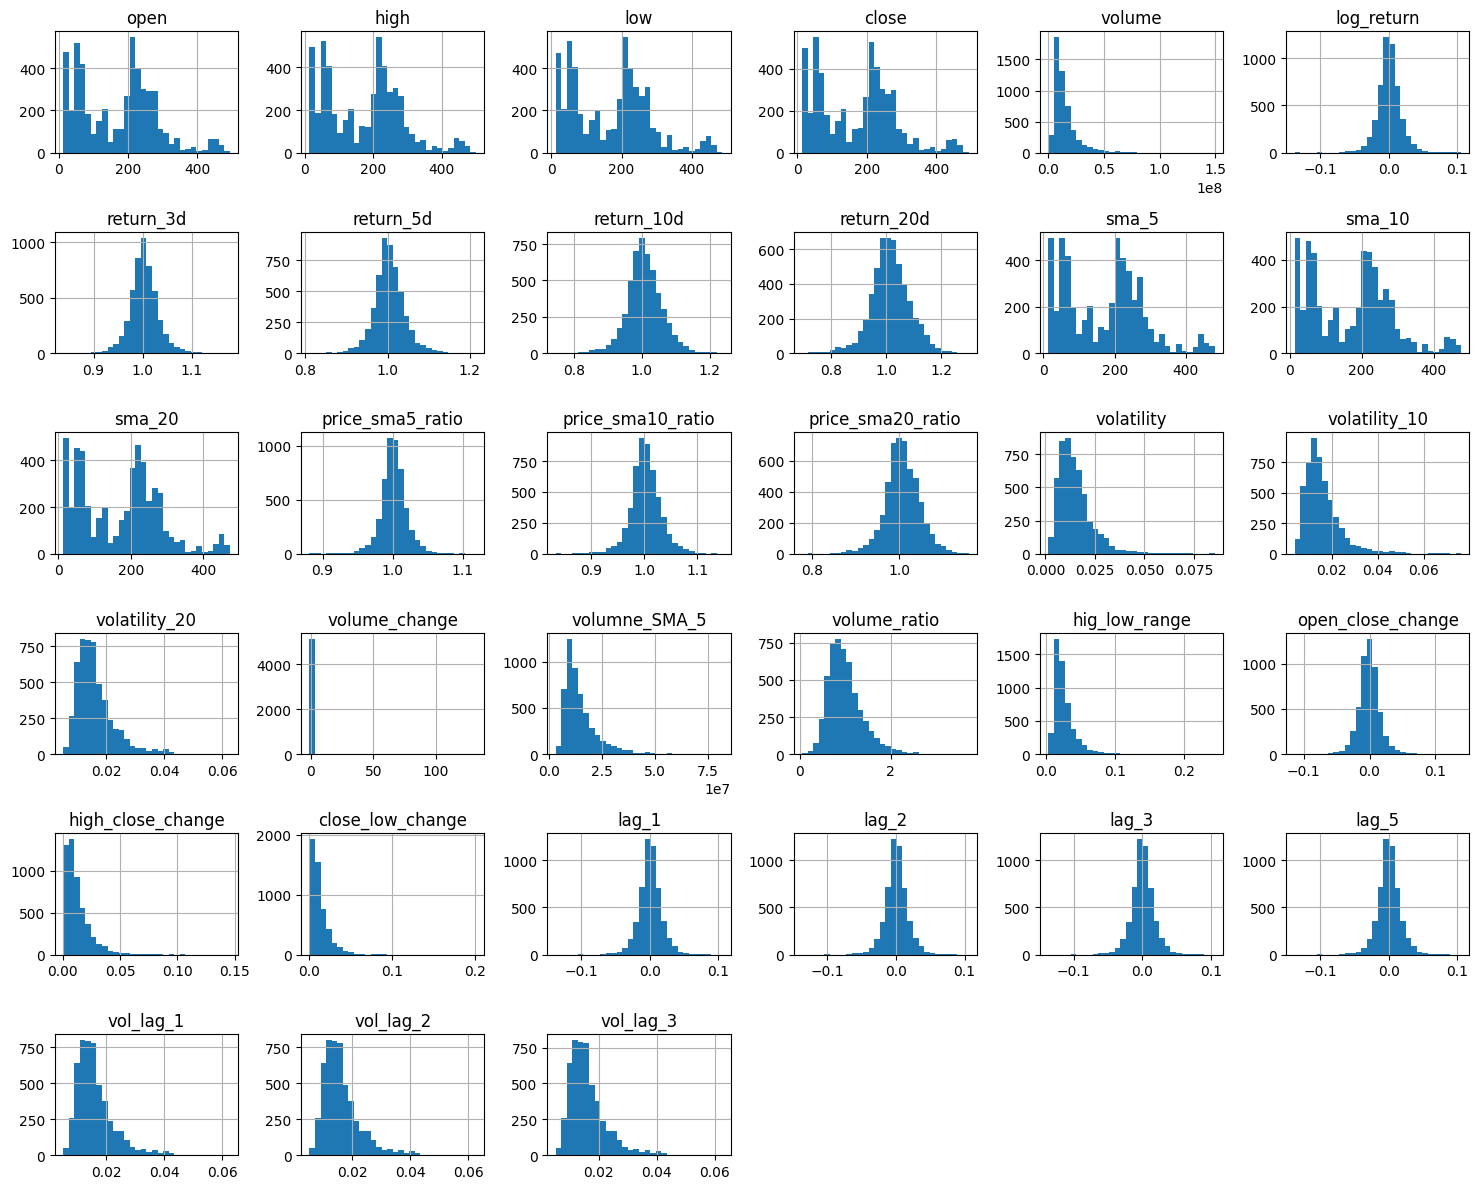

In [12]:
df[features].hist(figsize=(15,12),bins=30)
plt.tight_layout()
plt.show()

In [13]:
uni = df[features].describe().T
uni["skew"] = df[features].skew()
uni["missing"] = df[features].isna().sum()

uni.sort_values("skew", key=abs, ascending=False).head(8)

,count,mean,std,min,25%,50%,75%,max,skew,missing
volume_change,5166.0,1.815365e-01,2.027237e+00,-9.625520e-01,-2.806409e-01,-2.294313e-02,3.494431e-01,1.319093e+02,53.859015,0
close_low_change,5166.0,1.299356e-02,1.280259e-02,2.414876e-04,5.019840e-03,9.328364e-03,1.650565e-02,2.009412e-01,3.679972,0
volume,5166.0,1.497808e+07,1.143907e+07,4.570910e+05,8.278040e+06,1.160745e+07,1.755236e+07,1.494797e+08,3.470109,0
hig_low_range,5166.0,2.609479e-02,1.724608e-02,2.736914e-03,1.566523e-02,2.149485e-02,3.086305e-02,2.449446e-01,3.263983,0
high_close_change,5166.0,1.310123e-02,1.218750e-02,3.165559e-04,5.122673e-03,9.514894e-03,1.694790e-02,1.457794e-01,2.793199,0
volumne_SMA_5,5166.0,1.498010e+07,8.838739e+06,3.120606e+06,9.351740e+06,1.235347e+07,1.755669e+07,8.168508e+07,2.469939,0
volatility,5166.0,1.522664e-02,9.278344e-03,1.433280e-03,9.032585e-03,1.318395e-02,1.877627e-02,8.557201e-02,2.176387,0
volatility_10,5166.0,1.591367e-02,7.852558e-03,3.992303e-03,1.078241e-02,1.415371e-02,1.902816e-02,7.607158e-02,2.039437,0


**Bi-variate Analysis**

feature Vs next day return

In [14]:
corr = df[features+[target]].corr()
pearson = corr[target].drop(target).sort_values(key=abs, ascending=False)

spearman = df[features+[target]].corr(method="spearman")
spearman = spearman[target].drop(target).sort_values(key=abs, ascending=False)

print("Pearson:\n",pearson)
print("\nSpearman:\n",spearman)

Pearson:
 return_20d          -0.055914
return_3d           -0.047566
price_sma5_ratio    -0.045769
price_sma20_ratio   -0.043579
price_sma10_ratio   -0.040313
volume_ratio         0.039123
return_5d           -0.033513
lag_2               -0.033336
high_close_change    0.029587
return_10d          -0.027417
volume               0.026805
lag_1               -0.026065
close               -0.025605
low                 -0.025477
high                -0.025323
open                -0.025267
sma_5               -0.024682
sma_10              -0.024308
sma_20              -0.023556
log_return          -0.022238
open_close_change   -0.021988
hig_low_range        0.013268
lag_5               -0.010919
lag_3               -0.010595
vol_lag_3            0.010303
close_low_change    -0.010292
vol_lag_2            0.009927
vol_lag_1            0.006939
volatility_20        0.005379
volatility          -0.004899
volume_change        0.002140
volumne_SMA_5       -0.001476
volatility_10       -0.000671


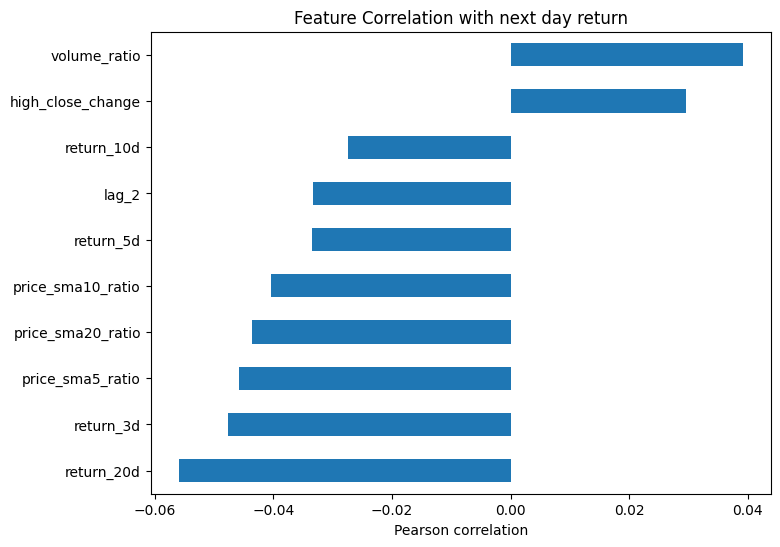

In [15]:
top = pearson.abs().sort_values(ascending=False).head(10).index

pearson[top].sort_values().plot(
    kind="barh",
    figsize=(8,6),
    title = "Feature Correlation with next day return"
)
plt.xlabel("Pearson correlation")
plt.show()

**Multi-Variate analysis**

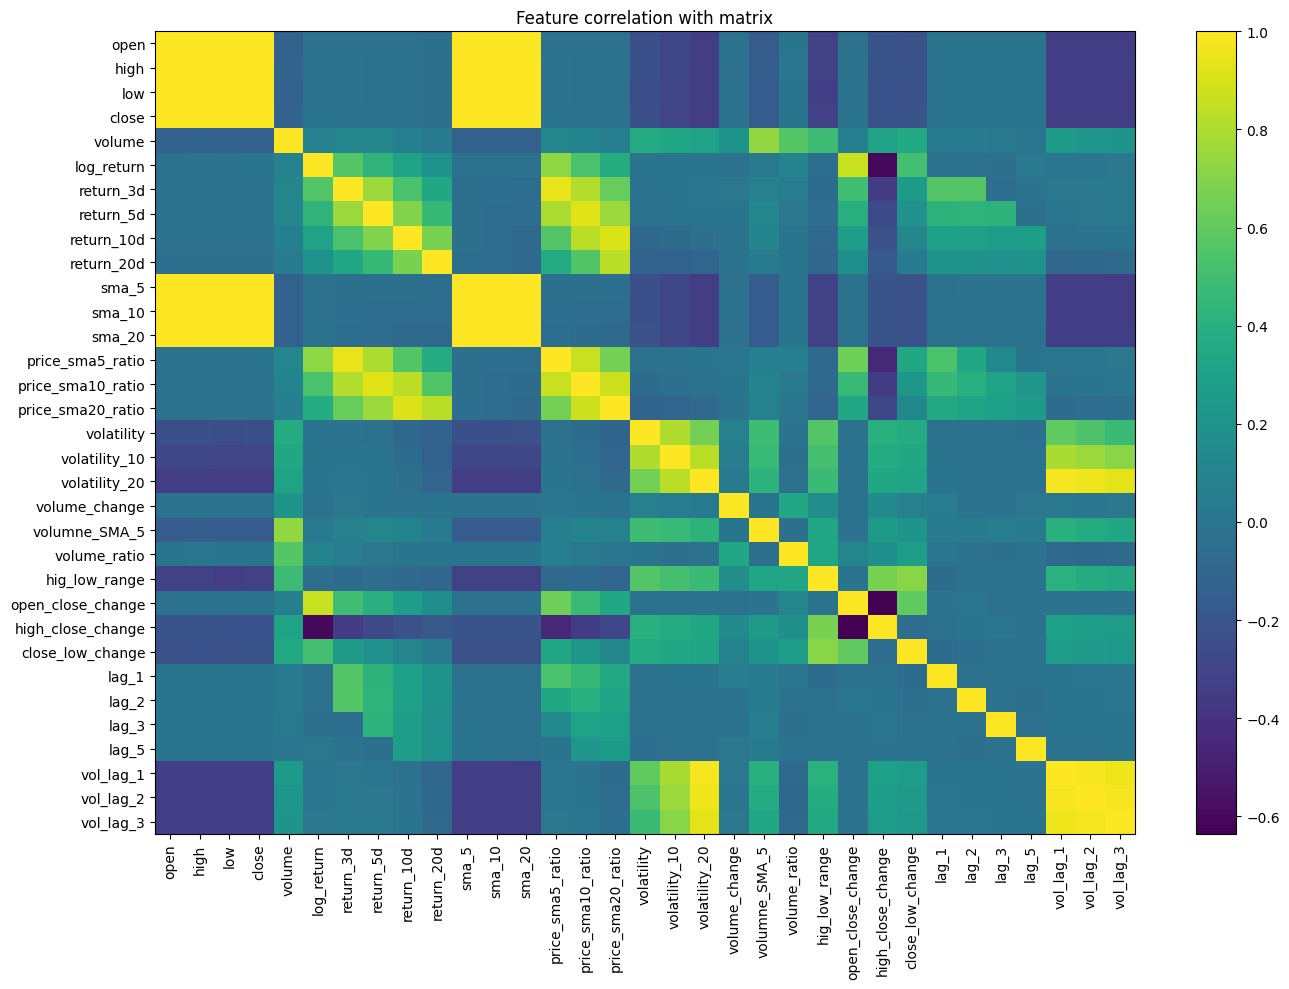

In [16]:
plt.figure(figsize=(14,10))

plt.imshow(df[features].corr(),aspect='auto')
plt.colorbar()

plt.xticks(range(len(features)),features,rotation=90)
plt.yticks(range(len(features)),features)

plt.title("Feature correlation with matrix")
plt.tight_layout()
plt.show()

**Train/Test split**

In [17]:
train = df[df.date < "2021-01-01"]
val   = df[(df.date >= "2021-01-01") & (df.date < "2023-01-01")]
test  = df[df.date >= "2023-01-01"]

X_train, y_train = train[features], train[target]
X_val, y_val     = val[features], val[target]
X_test, y_test   = test[features], test[target]

**Baseline Model**

In [18]:
baseline_pred = np.zeros(len(y_test))

**Linear regression**

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)

lr = LinearRegression().fit(X_tr,y_train)

y_pred_lr = lr.predict(X_te)
lr_prediction = lr.predict(X_te)

**XGBoost**

In [20]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=.03,
    subsample=.8,
    colsample_bytree=.8,
    objective="reg:squarederror",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

**Common evaluation**

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y, p):
    return [
        name,
        np.sqrt(mean_squared_error(y,p)),
        mean_absolute_error(y,p),
        r2_score(y,p),
        np.mean(np.sign(y)==np.sign(p))
    ]

In [23]:
results = pd.DataFrame([
    evaluate("Baseline", y_test, baseline_pred),
    evaluate("Linear Regression", y_test, y_pred_lr),
    evaluate("XGBoost", y_test, xgb_pred)
], columns=["Model","RMSE","MAE","R2","Direction"])

print(results)

               Model      RMSE       MAE        R2  Direction
0           Baseline  0.010895  0.008330 -0.014646   0.000000
1  Linear Regression  0.011629  0.008794 -0.156084   0.475096
2            XGBoost  0.015150  0.012063 -0.961926   0.455939


**KS_test**

Calculate model erros

In [25]:
errors = {
    "Linear":y_test.values - y_pred_lr,
    "XGBoost": y_test.values - xgb_pred
}

In [28]:
from scipy.stats import ks_2samp

ks,p = ks_2samp(errors["Linear"],errors["XGBoost"])
print("KS statistic:",ks)
print("p-value:",p)

KS statistic: 0.2796934865900383
p-value: 2.1480484011104124e-09


H0: Linear Regression and XGBoost have the same error distribution
H1: Their error distributions are different

if p < 0.05 the error distributions are statistically different.

p > 0.05 There is insufficient evidence to conclude that the error distribution differ.

**Mann-Whithney-U**

In [29]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    abs(errors["Linear"]),
    abs(errors["XGBoost"]),
    alternative="two-sided"
)

print("U:", u, "p-value:", p)

U: 26546.0 p-value: 1.2956224575641845e-05


This asks:

Is there evidence that the two models have different error magnitudes?

**Bootstrap confidence interval**

In [30]:
def bootstrap_ci(y, p, metric, n=2000):
    y, p = np.asarray(y), np.asarray(p)
    scores = [
        metric(y[i], p[i])
        for i in np.random.randint(len(y), size=(n, len(y)))
    ]
    return np.percentile(scores, [2.5, 97.5])

In [31]:
rmse = lambda y,p: np.sqrt(mean_squared_error(y,p))
mae = lambda y,p: mean_absolute_error(y,p)
direction = lambda y,p: np.mean(np.sign(y)==np.sign(p))

In [33]:
for name, pred in {
    "Linear": lr_prediction,
    "XGBoost": xgb_pred
}.items():

    print(name)
    print("RMSE CI:", bootstrap_ci(y_test, pred, rmse))
    print("MAE CI:", bootstrap_ci(y_test, pred, mae))
    print("Direction CI:", bootstrap_ci(y_test, pred, direction))

Linear
RMSE CI: [0.0103521  0.01299739]
MAE CI: [0.00790339 0.00972933]
Direction CI: [0.41752874 0.53639847]
XGBoost
RMSE CI: [0.01388232 0.01651514]
MAE CI: [0.01104544 0.01318785]
Direction CI: [0.39463602 0.51724138]


**XGBoost Feature importance**

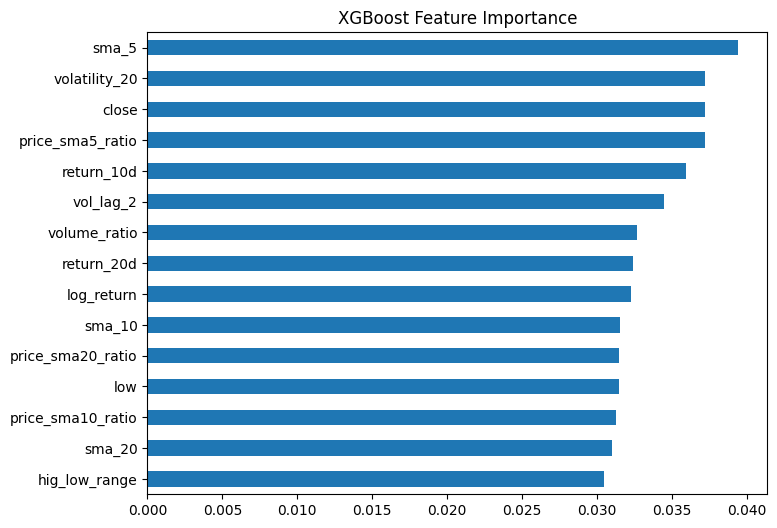

In [34]:
importance = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.head(15).plot(
    kind="barh",
    figsize=(8,6),
    title="XGBoost Feature Importance"
)

plt.gca().invert_yaxis()
plt.show()

**Best performing model**

In [40]:
pred = xgb_pred

signal = np.where(
    pred > .002, 1,
    np.where(pred < -.002, -1, 0)
)

strategy_return = signal * y_test.values
equity = (1 + strategy_return).cumprod()

In [41]:
buy_hold = (1 + y_test.values).cumprod()

**Risk Metrics**

In [42]:
sharpe = np.sqrt(252) * strategy_return.mean() / strategy_return.std()

drawdown = equity / np.maximum.accumulate(equity) - 1

print("Strategy Return:", equity[-1]-1)
print("Sharpe:", sharpe)
print("Max Drawdown:", drawdown.min())

Strategy Return: -0.29671916314462987
Sharpe: -1.8944191629082776
Max Drawdown: -0.33797291474829216
